In [1]:
import numpy as np
import matplotlib.pyplot as plt
from uniformity_fit import *
from flatness import *
import csv
import tifffile as tiff
import os
from YAG_RCF_analysis import *

In [2]:

def dose_CLEAR(PV,nOD0, channel):
    if channel ==0:
        a=4.6093
        b=0.1574 
        c=4.6606
    elif channel ==1:
        a=7.9162
        b=0.0418
        c=7.9213
    elif channel ==2:
        a=23.5294,
        b=0.1614, 
        c=23.2037

    OD = -np.log(PV/65535)
    nOD = OD - nOD0
    exp_term = np.exp(-nOD)
    return (a - c * exp_term) / (exp_term - b)


[0.35234978627190006, 0.41903358644952027, 0.7570667309664627]

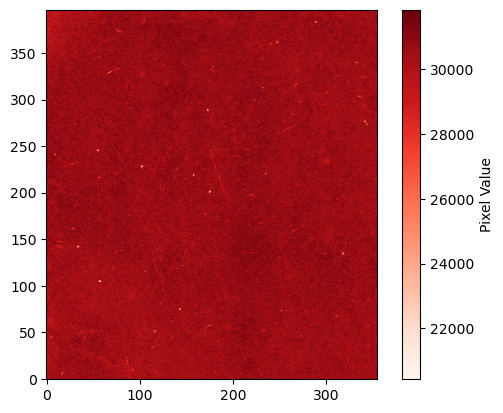

In [6]:
OD0s = []
for channel in [0,1,2]:
    bkgd1 = tiff.imread('CLEAR_experiments/May2026/scatterer_15-05_2026_21h/G_025.tif')[50:-25,25:-25,channel]
    bkgd2 = tiff.imread('CLEAR_experiments/May2026/scatterer_15-05_2026_21h/G_026.tif')[50:-25,25:-25,channel]
    OD0s.append(-np.log(np.mean([bkgd1, bkgd2])/65535))



channel = 0


if channel == 1:
    cmap = 'Greens'

elif channel ==0:
    cmap = "Reds"

plt.imshow(bkgd1, cmap=cmap, origin='lower')
plt.colorbar(label="Pixel Value")
OD0s



In [ ]:
# channel = 0
# filename = 'G_001'

# folder = 'CLEAR_dosimetry/FilmDosimetryGUI_macOS/scatterer_15-05_2026_21h/'

# path = folder + filename + ".tif"
# film = tiff.imread(path)[25:-25,25:-25,channel]

# plt.imshow(film,cmap = cmap)
# plt.colorbar()
# # films.show()  # display image
# # flipped_h = films.transpose(Image.FLIP_LEFT_RIGHT)

# # film_array = np.array(film)


In [7]:
film = tiff.imread('CLEAR_dosimetry/FilmDosimetryGUI_macOS/scatterer_15-05_2026_21h/G_008.tif')[25:-25,25:-25,channel]

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sabrinawang/Desktop/DPhil_Project/CLEAR_dosimetry/FilmDosimetryGUI_macOS/scatterer_15-05_2026_21h/G_008.tif'

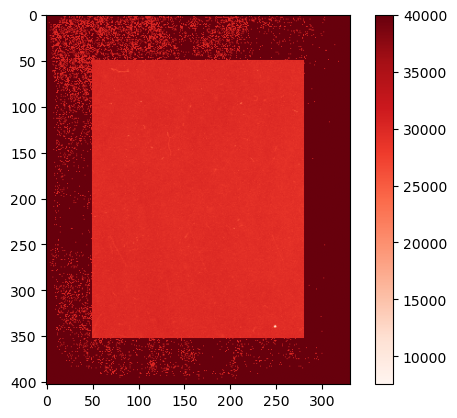

In [8]:
def remove_marking(film):
    h, w = film.shape
    mask = np.ones((h, w), dtype=bool)
    mask[50:-50, 50:-50] = False


    film[(mask) & (film < 30000)] = 40000
    plt.imshow(film,cmap = cmap)
    return film

film = remove_marking(film)

plt.imshow(film,cmap = cmap)
plt.colorbar()

In [ ]:
csv_path = "CLEAR_experiments/May2026/15_05_2026film_parameters.csv"
fig_dir = "CLEAR_experiments/May2026/RCF_output_figs/small_new"
tif_dir = "CLEAR_experiments/May2026/scatterer_15-05_2026_21h"

os.makedirs(fig_dir, exist_ok=True)

existing_csv_entries = set()

if os.path.exists(csv_path):
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if row and row[0] != "film":
                existing_csv_entries.add(row[0])

write_header = not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "film",
            "cx", "cy",
            "dose_centre",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y",
            "dose_std",
            "errPx", "errPy",
            "err_x90_x","err_x90_y"
        ])

    for i in range(1, 25):
        if i < 10:
            filename = f"G_00{i}"    
        else:
            filename = f"G_0{i}"

        out_name = f"{filename}_dose_profile.png"
        out_path = os.path.join(fig_dir, out_name)

        csv_line_exists = filename in existing_csv_entries
        image_exists = os.path.exists(out_path)

        if csv_line_exists and image_exists:
            print(f"Skipping {filename}: CSV entry and image already exist.")
            continue

        print(f"Running {filename}")

        path = os.path.join(tif_dir, filename + ".tif")

        film = tiff.imread(path)[25:-25, 25:-25, channel]
        film_flipped = np.flipud(film)

        dose = dose_CLEAR(film_flipped, OD0s[channel], channel)
        dose[dose > 25] = 4

        fig, cx, cy, dose_centre, Px, Py, r90_x, r90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y = plot_dose1(dose, "RCF")

        plt.savefig(out_path)
        plt.close(fig)

        if not csv_line_exists:
            writer.writerow([
                filename,
                cx, cy,
                dose_centre,
                Px, Py,
                r90_x, r90_y,
                ratio_x, ratio_y,
                dose_std,
                errPx, errPy,
                err_x90_x, err_x90_y
            ])
            existing_csv_entries.add(filename)

Running G_001
Running G_002
Running G_003
Running G_004
Running G_005
Running G_006
Running G_007
Running G_008
Running G_009
Running G_010
Running G_011
Running G_012
Running G_013
Running G_014
Running G_015
Running G_016
Running G_017
Running G_018
Running G_019


/Users/sabrinawang/Desktop/DPhil_Project/uniformity_fit.py:18: RuntimeWarning: overflow encountered in power
  return A * np.exp(-( (x-x0)**2 /(2*sigma_x**2) )**P) + m * x + c


Running G_020
Running G_021
Running G_022
Running G_023
Running G_024


13th May

In [4]:
OD0s = []
for channel in [0,1,2]:
    bkgd1 = tiff.imread('CLEAR_experiments/May2026/scatterer_13-05_2026_44h/F_023.tif')[50:-25,25:-25,channel]
    bkgd2 = tiff.imread('CLEAR_experiments/May2026/scatterer_13-05_2026_44h/F_024.tif')[50:-25,25:-25,channel]
    OD0s.append(-np.log(np.mean([bkgd1, bkgd2])/65535))



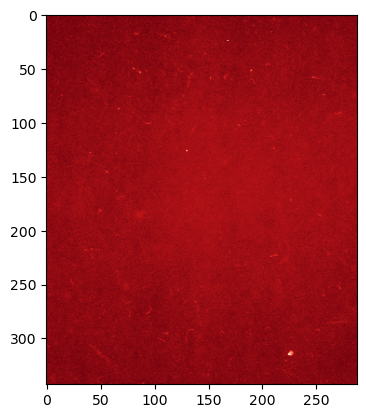

In [9]:
filmname = 'F_020'
# film = tiff.imread('CLEAR_experiments/May2026/scatterer_13-05_2026_44h/'+ filmname + '.tif')[30:-40,40:-40,channel]
film = np.load('CLEAR_experiments/May2026/scatterer_13-05_2026_44h/'+ filmname + '.npy')[10:-5,7:-5]
plt.imshow(film, cmap=cmap)

In [7]:
np.save(f'CLEAR_experiments/May2026/scatterer_13-05_2026_44h/'+ filmname + '.npy', film)

Running F_001
Skipping F_001: fit or plotting failed (Optimal parameters not found: Number of calls to function has reached maxfev = 1400.)
Running F_002
Running F_003
Running F_004
Running F_005
Running F_006
Running F_007
Running F_008
Running F_009
Running F_010
Running F_011
Running F_012
Running F_013
Running F_014
Running F_015
Running F_016
Running F_017
Running F_018
Running F_019
Running F_020
Running F_021
Skipping F_021: fit or plotting failed (Optimal parameters not found: Number of calls to function has reached maxfev = 1400.)
Running F_022
Skipping F_022: fit or plotting failed ([Errno 2] No such file or directory: 'CLEAR_experiments/May2026/scatterer_13-05_2026_44h/F_022.npy')
Running F_023
Skipping F_023: fit or plotting failed ([Errno 2] No such file or directory: 'CLEAR_experiments/May2026/scatterer_13-05_2026_44h/F_023.npy')
Running F_024
Skipping F_024: fit or plotting failed ([Errno 2] No such file or directory: 'CLEAR_experiments/May2026/scatterer_13-05_2026_44h/F

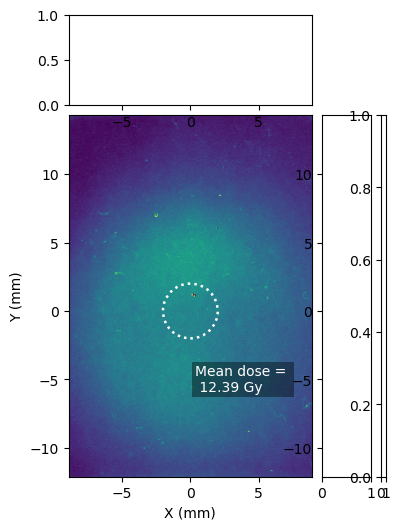

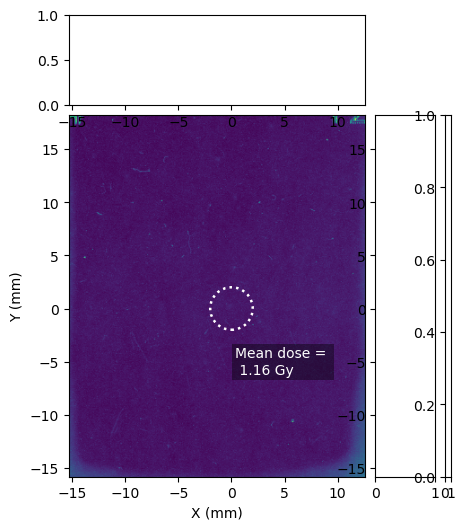

In [ ]:
csv_path = "CLEAR_experiments/May2026/13_05_2026film_parameters.csv"
fig_dir = "CLEAR_experiments/May2026/RCF_output_figs/large_new"
tif_dir = "CLEAR_experiments/May2026/scatterer_13-05_2026_44h"

os.makedirs(fig_dir, exist_ok=True)

existing_csv_entries = set()

if os.path.exists(csv_path):
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if row and row[0] != "film":
                existing_csv_entries.add(row[0])

write_header = not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "film",
            "cx", "cy",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y",
            "dose_std",
            "errPx", "errPy",
            "err_x90_x", "err_x90_y"
        ])

    for i in range(1, 25):
        if i < 10:
            filename = f"F_00{i}"
        else:
            filename = f"F_0{i}"

        out_name = f"{filename}_dose_profile.png"
        out_path = os.path.join(fig_dir, out_name)

        csv_line_exists = filename in existing_csv_entries
        image_exists = os.path.exists(out_path)

        if csv_line_exists and image_exists:
            print(f"Skipping {filename}: CSV entry and image already exist.")
            continue

        print(f"Running {filename}")

        path = os.path.join(tif_dir, filename + ".npy")

        try:
            film = np.load(path)
            film_flipped = np.flipud(film)

            dose = dose_CLEAR(film_flipped, OD0s[channel], channel)
            dose[dose > 25] = 4

            fig, cx, cy, dose_centre, Px, Py, r90_x, r90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y = plot_dose1(dose, "RCF")

        except Exception as e:
            print(f"Skipping {filename}: fit or plotting failed ({e})")
            continue

        try:
            fig.savefig(out_path)
        finally:
            plt.close(fig)

        if not csv_line_exists:
            writer.writerow([
                filename,
                cx, cy,
                dose_centre,
                r90_x, r90_y,
                ratio_x, ratio_y,
                dose_std,
                errPx, errPy,
                err_x90_x, err_x90_y
            ])
            existing_csv_entries.add(filename)